<a href="https://colab.research.google.com/github/waghvaishnav/Deep-Learning-PlayGround-Hub/blob/main/Transfer_Learning_101Caltech_Img_Classification_(ResNet%2CEfficientNet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Transfer Learning: Image Classification

* importing required modules

In [ ]:
import torch
import torch.optim as optim
from torchvision import datasets,transforms,models
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torch.nn as nn

In [ ]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
device

'cpu'

* Loading Clatech101 Dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),  # ✅ BEFORE ToTensor
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

dataset = datasets.Caltech101(root="data",download=True,transform=transform)
len(dataset)

8677

In [ ]:
dataset.categories

['Faces',
 'Faces_easy',
 'Leopards',
 'Motorbikes',
 'accordion',
 'airplanes',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooster',
 'saxophone',
 'sc

In [ ]:
# splits datasets  into train,test dataset
train_size = int(len(dataset)*0.8)
test_size = (len(dataset) - train_size)

train_data,test_data = random_split(dataset,[train_size,test_size])

len(train_data),len(test_data)

(6941, 1736)

In [ ]:
train_loader = DataLoader(train_data,batch_size=32,shuffle=True)
test_loader = DataLoader(test_data,batch_size=32,shuffle=False)

* Visualizing the images

In [ ]:
for i,(images,labels) in enumerate(train_loader):
  print(images.shape)
  print(labels.shape)
  break

torch.Size([32, 3, 128, 128])
torch.Size([32])


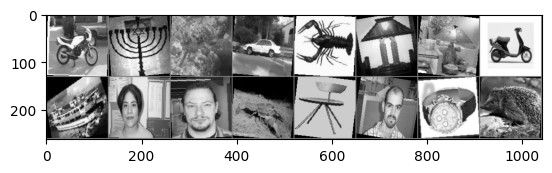

In [ ]:
def show_images(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.show()

show_images(torchvision.utils.make_grid(images[:16]))

In [ ]:
labels[:16]

tensor([ 3, 63, 47, 19, 27, 56, 56,  3, 40,  0,  1, 27, 22,  0, 94, 49])

In [ ]:
[dataset.categories[i] for i in labels[:16]]

['Motorbikes',
 'menorah',
 'hawksbill',
 'car_side',
 'crayfish',
 'lamp',
 'lamp',
 'Motorbikes',
 'ferry',
 'Faces',
 'Faces_easy',
 'crayfish',
 'chair',
 'Faces',
 'watch',
 'hedgehog']

In [ ]:
class CNN(nn.Module):
  def __init__(self,num_classes):
    super().__init__()

    # define layers:
    self.network = nn.Sequential(
        nn.Conv2d(3,32,kernel_size=(3,3),padding="same"),  # (32,128,128)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),       # (32,64,64)

        nn.Conv2d(32,64,kernel_size=(3,3),padding="same"),       # (64,64,64)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),       # (64,32,32)

        nn.Flatten(),
        nn.Linear(64*32*32,256),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,num_classes)
    )

  def forward(self,x):
    return self.network(x)



In [ ]:
# model training:
def model_training(model,optimizer,criterion,train_loader,test_loader,num_epochs=5):
  model.train()
  for epoch in range(num_epochs):

    running_loss = 0.0

    for i,(images,labels) in enumerate(train_loader):
      output = model(images)
      loss = criterion(output,labels)

      # backpropagation:
      optimizer.zero_grad()
      loss.backward()

      # weight updation:
      optimizer.step()

      running_loss += loss.item()
    print(f"epoch {epoch+1} / {num_epochs}, loss: {running_loss/len(train_loader):.4f}")



In [ ]:
num_classes = len(dataset.categories)
num_classes

101

In [ ]:
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)


model_training(model,optimizer,criterion,train_loader,test_loader,num_epochs=5)

epoch 1 / 5, loss: 3.4033
epoch 2 / 5, loss: 2.4884
epoch 3 / 5, loss: 2.0182
epoch 4 / 5, loss: 1.6947
epoch 5 / 5, loss: 1.4216


In [ ]:
def test_model(model,test_loader):
  model.eval()

  correct = 0
  total = 0

  with torch.no_grad():
    for images,labels in test_loader:
      images,labels = images.to(device),labels.to(device)
      output = model(images)

      _,predicted = torch.max(output,1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  print(f"Total Accuracy of the validation is : {correct / total:.4f}")




In [ ]:
test_model(model,test_loader)

Total Accuracy of the validation is : 0.5386


## Transfer Learning : ResNet / EfficientNet for Image Classification

* ResNet18 Pre-Trained Model

In [ ]:
from torchvision import models

# load the pre-trained resnet18 model
model = models.resnet18(weights="DEFAULT")

# replace the fully connected layers
model.fc = nn.Linear(model.fc.in_features,num_classes)

# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

model_training(model,optimizer,criterion,train_loader,test_loader,num_epochs=5)
test_model(model,test_loader)

epoch 1 / 5, loss: 2.0471
epoch 2 / 5, loss: 1.1133
epoch 3 / 5, loss: 0.7708
epoch 4 / 5, loss: 0.5933
epoch 5 / 5, loss: 0.4713
Total Accuracy of the validation is : 0.7776


* EfficientNet_b0 Pre-Trained Model

In [ ]:
# load the pre-trained model
model = models.efficientnet_b0(weights="DEFAULT")

model.classifier[1] = nn.Linear(model.classifier[1].in_features,num_classes)
model = model.to(device)

# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

model_training(model,optimizer,criterion,train_loader,test_loader,num_epochs=5)
test_model(model,test_loader)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s]


epoch 1 / 5, loss: 1.6153
epoch 2 / 5, loss: 0.6032
epoch 3 / 5, loss: 0.3994
epoch 4 / 5, loss: 0.2675
epoch 5 / 5, loss: 0.2286
Total Accuracy of the validation is : 0.8698
